In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('preprocessed.csv')

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,...,demand_lag5,demand_lag6,demand_lag7,Units Sold_lag1,Units Sold_lag2,Units Sold_lag3,Units Sold_lag4,Units Sold_lag5,Units Sold_lag6,Units Sold_lag7
0,2022-01-08,S001,P0001,Electronics,308,96,0.0,68.56,10,Snowy,...,132.0,84.0,115.0,92.0,98.0,129.0,42.0,142.0,71.0,102.0
1,2022-01-09,S001,P0001,Electronics,212,57,248.0,62.76,10,Sunny,...,67.0,132.0,84.0,96.0,92.0,98.0,129.0,42.0,142.0,71.0
2,2022-01-10,S001,P0001,Electronics,403,88,0.0,68.99,5,Cloudy,...,110.0,67.0,132.0,57.0,96.0,92.0,98.0,129.0,42.0,142.0
3,2022-01-11,S001,P0001,Electronics,315,112,0.0,73.71,0,Cloudy,...,146.0,110.0,67.0,88.0,57.0,96.0,92.0,98.0,129.0,42.0
4,2022-01-12,S001,P0001,Electronics,203,70,0.0,65.76,10,Snowy,...,87.0,146.0,110.0,112.0,88.0,57.0,96.0,92.0,98.0,129.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75300 entries, 0 to 75299
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 75300 non-null  str    
 1   Store ID             75300 non-null  str    
 2   Product ID           75300 non-null  str    
 3   Category             75300 non-null  str    
 4   Inventory Level      75300 non-null  int64  
 5   Units Sold           75300 non-null  int64  
 6   Units Ordered        75300 non-null  float64
 7   Price                75300 non-null  float64
 8   Discount             75300 non-null  int64  
 9   Weather Condition    75300 non-null  str    
 10  Promotion            75300 non-null  int64  
 11  Competitor Pricing   75300 non-null  float64
 12  Seasonality          75300 non-null  str    
 13  Epidemic             75300 non-null  int64  
 14  Demand               75300 non-null  int64  
 15  Price_Premium_Index  75300 non-null  float64
 1

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df =df[(df['Category'] == 'Electronics') & (df['Store ID'] == 'S001') & (df['Product ID'] == 'P0001')]


In [7]:
df.sort_values('Date', inplace=True)

In [8]:
df['Date'].describe()

count                    753
mean     2023-01-19 00:00:00
min      2022-01-08 00:00:00
25%      2022-07-15 00:00:00
50%      2023-01-19 00:00:00
75%      2023-07-26 00:00:00
max      2024-01-30 00:00:00
Name: Date, dtype: object

In [9]:
df.set_index('Date', inplace=True)

In [10]:
import joblib

ct = joblib.load('ColumnTransformer.pkl')

imputer = joblib.load("imputer.pkl")

model = joblib.load("xgb_model.pkl")

In [11]:
x = df.drop(['Units Sold', 'Demand'], axis=1)
y = df[['Units Sold', 'Demand']]

In [12]:
x = ct.transform(x)
x = np.where(np.isinf(x), np.nan, x)
x = imputer.transform(x)

In [13]:
x.shape, y.shape

((753, 65), (753, 2))

In [14]:
predictions = model.predict(x)

In [15]:
predictions[0]

array([104.45067596, 114.99523163])

In [16]:
df['predicted Units Sold'] = predictions[:,0]
df['predicted Demand'] = predictions[:,1]

In [17]:
df.columns

Index(['Store ID', 'Product ID', 'Category', 'Inventory Level', 'Units Sold',
       'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion',
       'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Price_Premium_Index', 'Discount_Depth', 'Day_of_Week', 'Is_Weekend',
       'Month', 'Day_of_Month', 'demand_lag1', 'demand_lag2', 'demand_lag3',
       'demand_lag4', 'demand_lag5', 'demand_lag6', 'demand_lag7',
       'Units Sold_lag1', 'Units Sold_lag2', 'Units Sold_lag3',
       'Units Sold_lag4', 'Units Sold_lag5', 'Units Sold_lag6',
       'Units Sold_lag7', 'predicted Units Sold', 'predicted Demand'],
      dtype='str')

<Axes: title={'center': 'Actual Units Sold'}, xlabel='Date'>

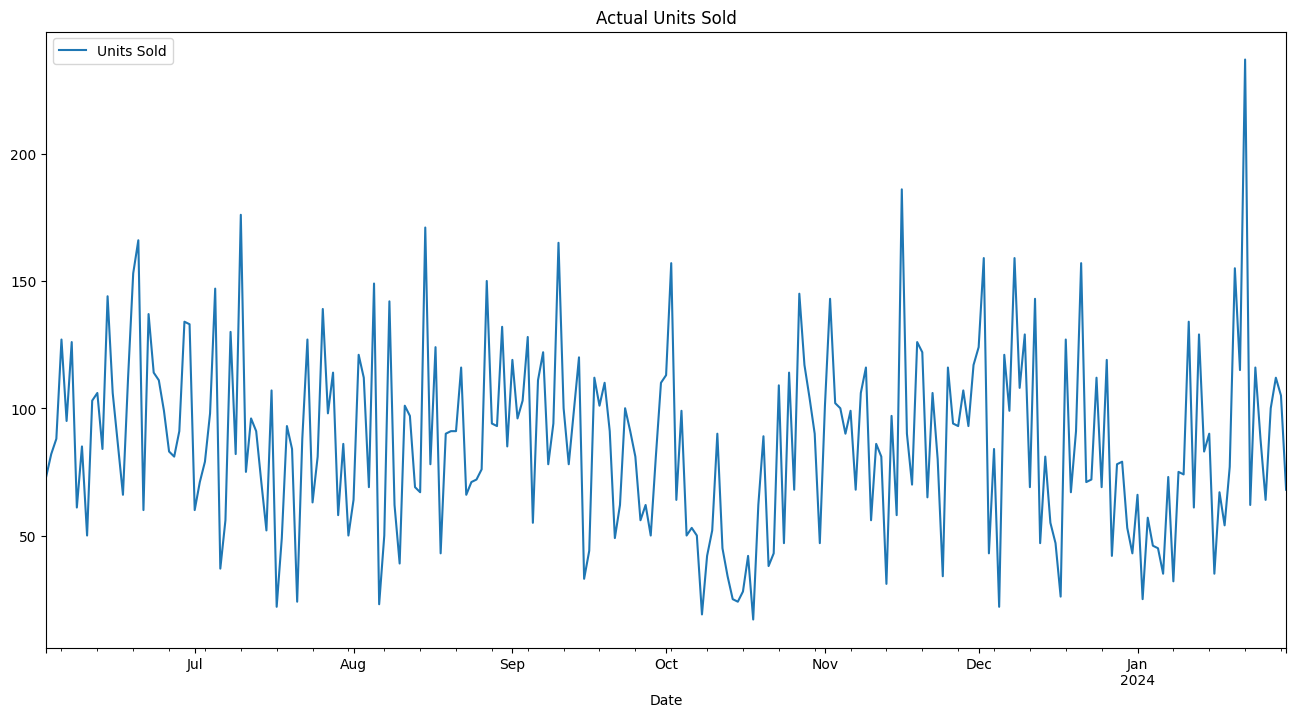

In [18]:
df[['Units Sold']][df.index > '2023-06-01'].plot(figsize=(16,8), title='Actual Units Sold')

<Axes: title={'center': ' Predicted Units Sold'}, xlabel='Date'>

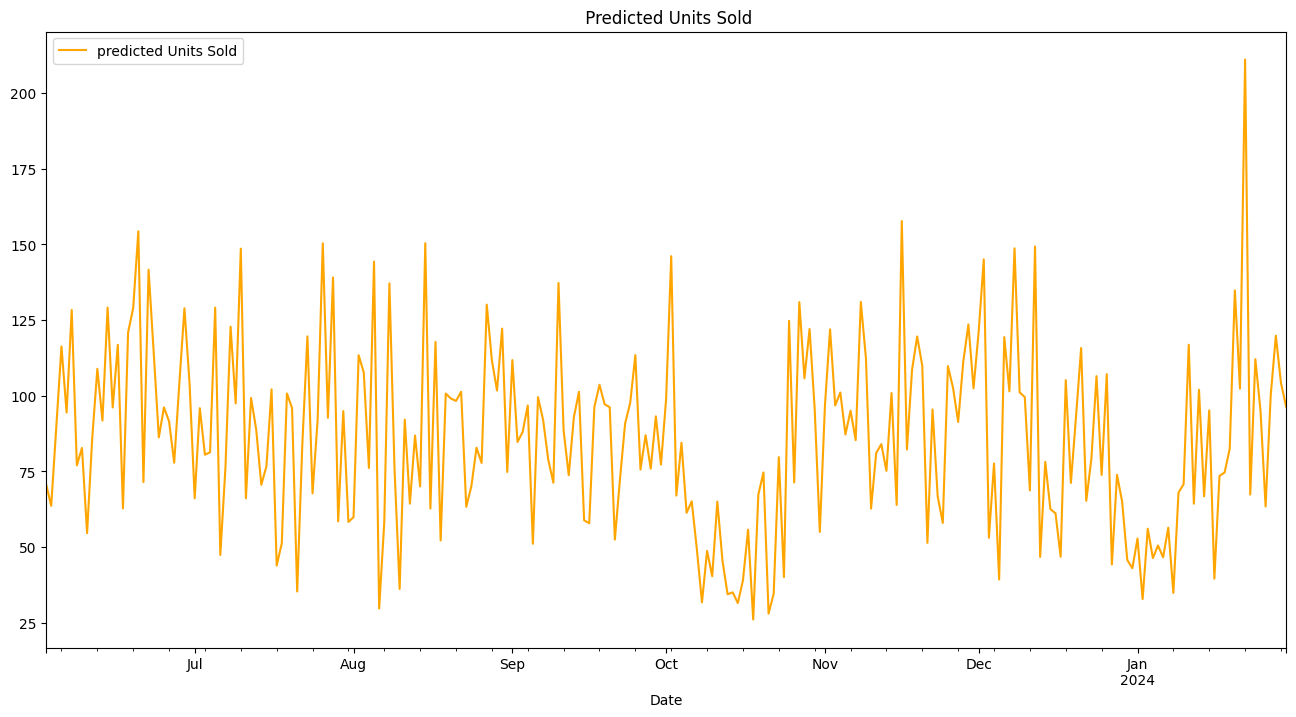

In [19]:
df[[ 'predicted Units Sold']][df.index > '2023-06-01'].plot(figsize=(16,8), title=' Predicted Units Sold',color='orange')

<Axes: title={'center': 'Actual vs Predicted Units Sold'}, xlabel='Date'>

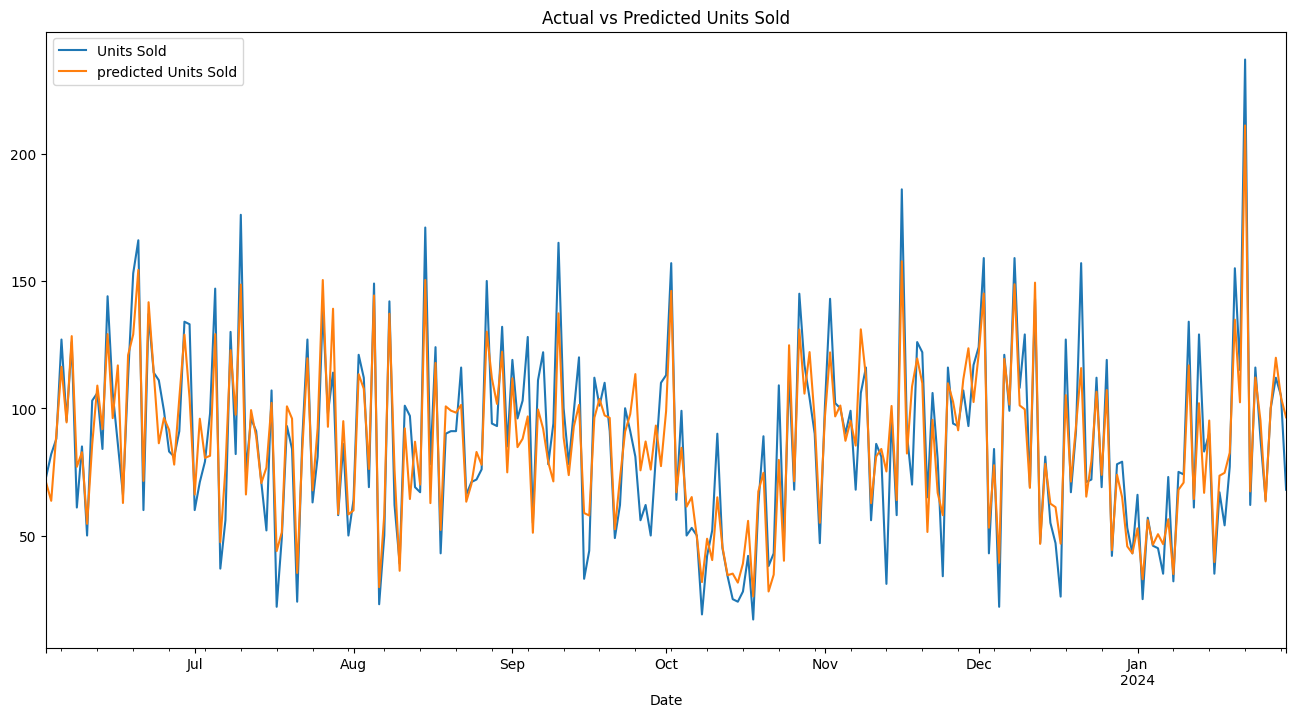

In [20]:
df[['Units Sold', 'predicted Units Sold']][df.index > '2023-06-01'].plot(figsize=(16,8), title='Actual vs Predicted Units Sold')

<Axes: title={'center': 'Actual Demand'}, xlabel='Date'>

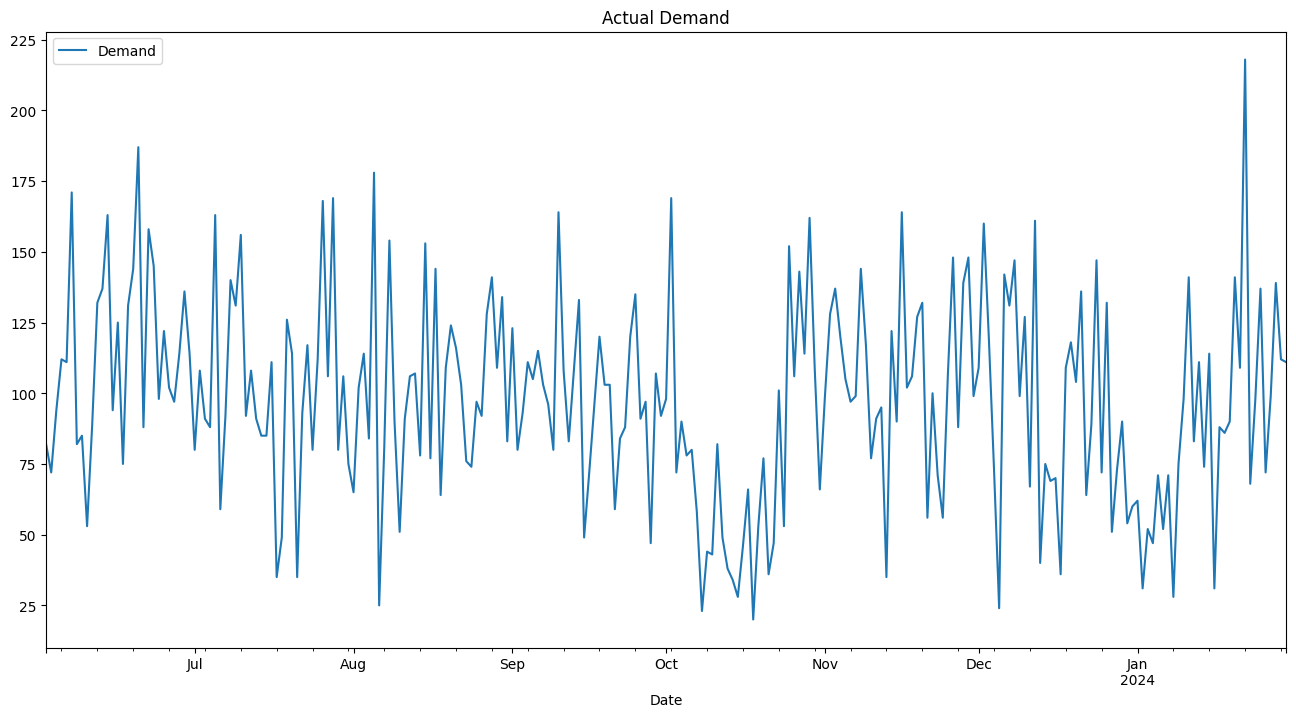

In [21]:
df[['Demand']][df.index > '2023-06-01'].plot(figsize=(16,8), title='Actual Demand')

<Axes: title={'center': ' Predicted Demand'}, xlabel='Date'>

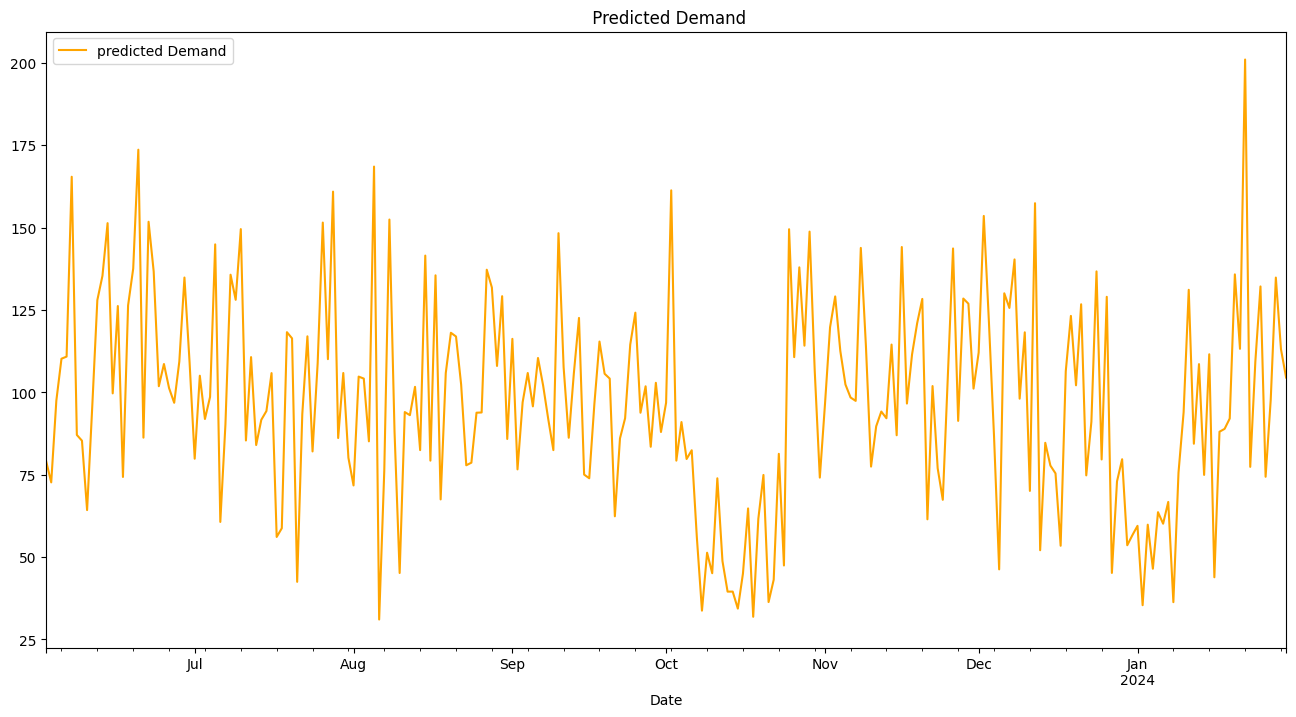

In [22]:
df[['predicted Demand']][df.index > '2023-06-01'].plot(figsize=(16,8), title=' Predicted Demand',color='orange')

<Axes: title={'center': 'Actual vs Predicted Demand'}, xlabel='Date'>

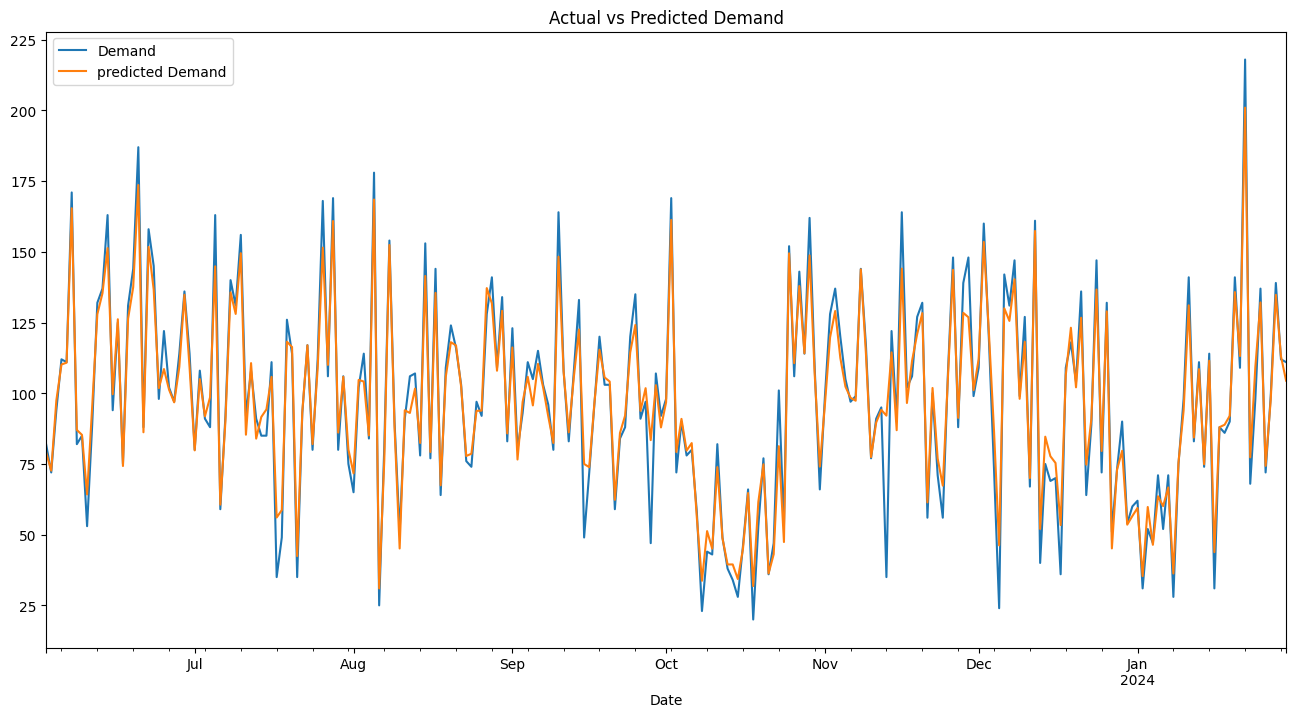

In [23]:
df[['Demand', 'predicted Demand']][df.index > '2023-06-01'].plot(figsize=(16,8), title='Actual vs Predicted Demand')

In [24]:
Demand_error = abs(df['Demand'] - df['predicted Demand'])
df['demand error'] = Demand_error
Units_Sold_error=  abs(df['Units Sold'] - df[ 'predicted Units Sold'])
df['units sold error'] = Units_Sold_error

In [25]:
print(Demand_error.describe(),Units_Sold_error.describe())

count    753.000000
mean       5.894519
std        5.514004
min        0.003624
25%        2.328369
50%        4.610962
75%        8.084106
max       57.093803
dtype: float64 count    753.000000
mean      10.864541
std        8.445219
min        0.006123
25%        4.719559
50%        8.897408
75%       15.260338
max       62.543243
dtype: float64


In [26]:
df.columns

Index(['Store ID', 'Product ID', 'Category', 'Inventory Level', 'Units Sold',
       'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion',
       'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Price_Premium_Index', 'Discount_Depth', 'Day_of_Week', 'Is_Weekend',
       'Month', 'Day_of_Month', 'demand_lag1', 'demand_lag2', 'demand_lag3',
       'demand_lag4', 'demand_lag5', 'demand_lag6', 'demand_lag7',
       'Units Sold_lag1', 'Units Sold_lag2', 'Units Sold_lag3',
       'Units Sold_lag4', 'Units Sold_lag5', 'Units Sold_lag6',
       'Units Sold_lag7', 'predicted Units Sold', 'predicted Demand',
       'demand error', 'units sold error'],
      dtype='str')

In [27]:
df['Discount'].value_counts()

Discount
10    239
0     173
5     163
25     65
15     62
20     51
Name: count, dtype: int64

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
demand_mean_value = df["demand error"].mean()
units_sold_mean_value = df["units sold error"].mean()

In [30]:
def plot(cat):
    sns.barplot(data=df, y="demand error", x=cat)
    plt.axhline(y=demand_mean_value, color="red", linestyle="--", linewidth=2, label=f"Mean")
    plt.show()

    sns.barplot(data=df, y="units sold error", x=cat)
    plt.axhline(y=units_sold_mean_value, color="red", linestyle="--", linewidth=2, label=f"Mean")
    plt.show()
    

In [31]:
df.columns

Index(['Store ID', 'Product ID', 'Category', 'Inventory Level', 'Units Sold',
       'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion',
       'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Price_Premium_Index', 'Discount_Depth', 'Day_of_Week', 'Is_Weekend',
       'Month', 'Day_of_Month', 'demand_lag1', 'demand_lag2', 'demand_lag3',
       'demand_lag4', 'demand_lag5', 'demand_lag6', 'demand_lag7',
       'Units Sold_lag1', 'Units Sold_lag2', 'Units Sold_lag3',
       'Units Sold_lag4', 'Units Sold_lag5', 'Units Sold_lag6',
       'Units Sold_lag7', 'predicted Units Sold', 'predicted Demand',
       'demand error', 'units sold error'],
      dtype='str')

In [32]:
li =df.select_dtypes(object).columns.to_list()
li.remove("Store ID")
li.remove("Product ID")
li.remove('Category')
print(li)

['Weather Condition', 'Seasonality']


C:\Users\kumar\AppData\Local\Temp\ipykernel_27416\2747031257.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  li =df.select_dtypes(object).columns.to_list()


In [33]:
li.append("Discount")
li.append('Epidemic')
li.append('Is_Weekend')

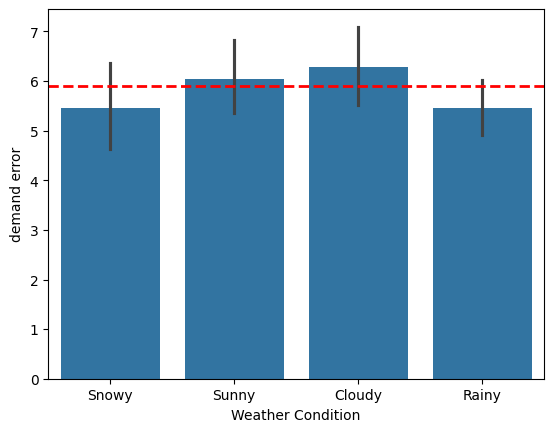

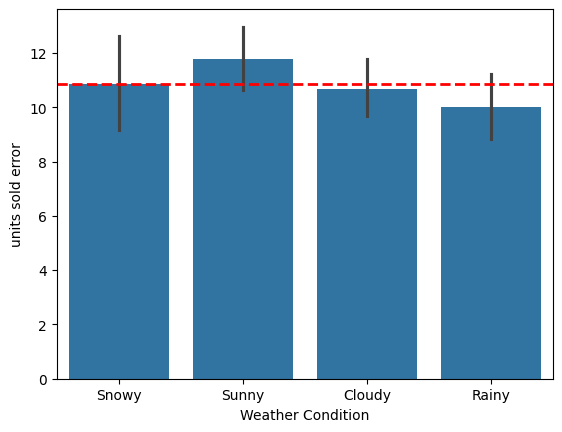

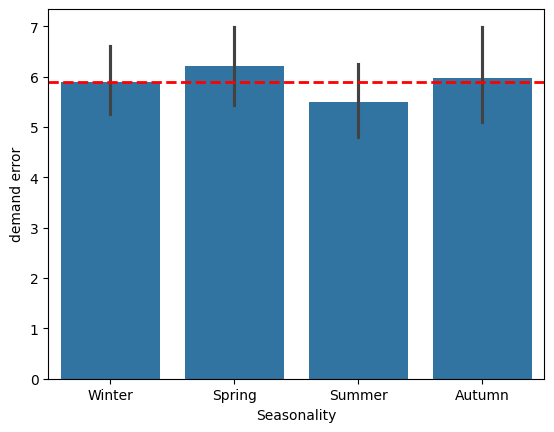

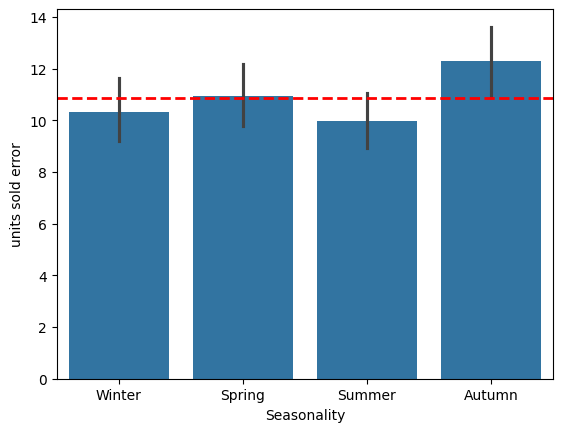

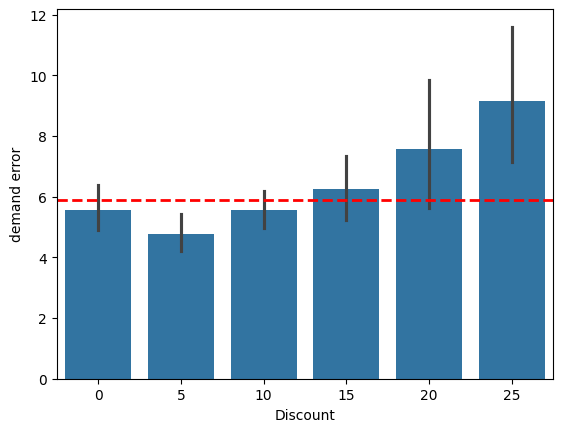

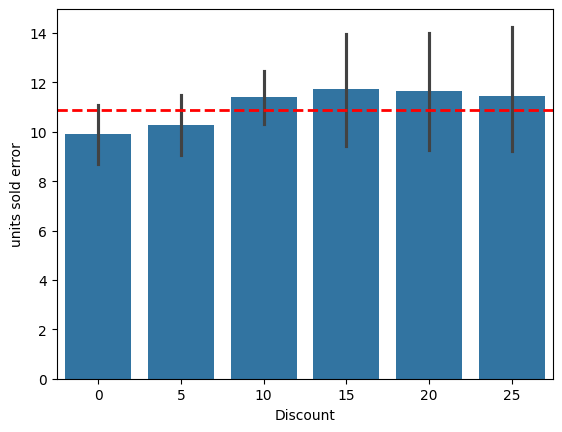

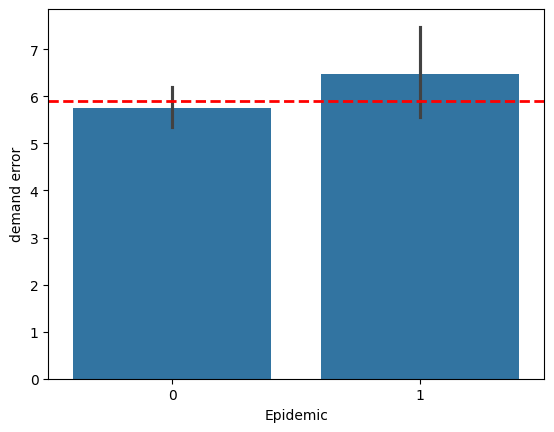

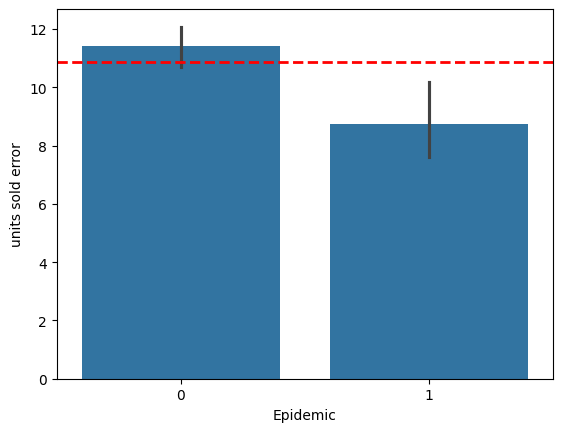

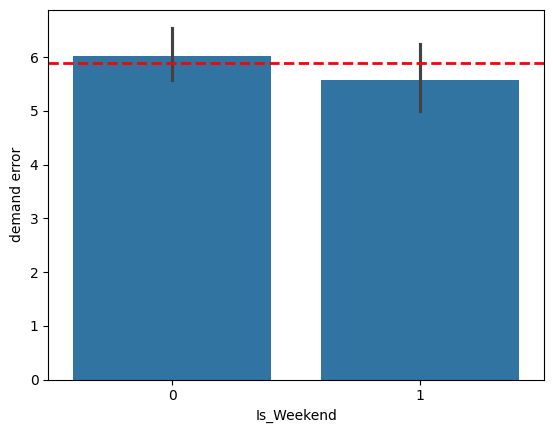

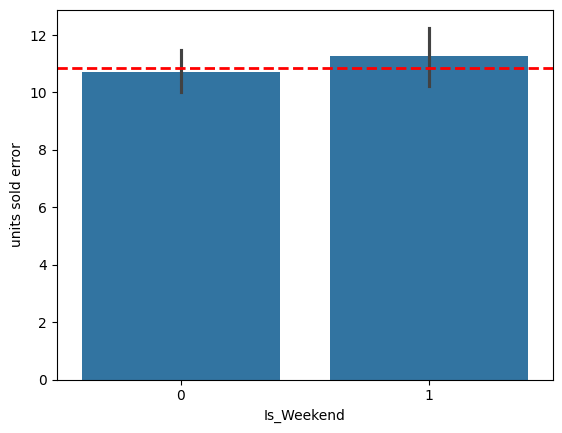

In [34]:
for i in li:
    plot(i)